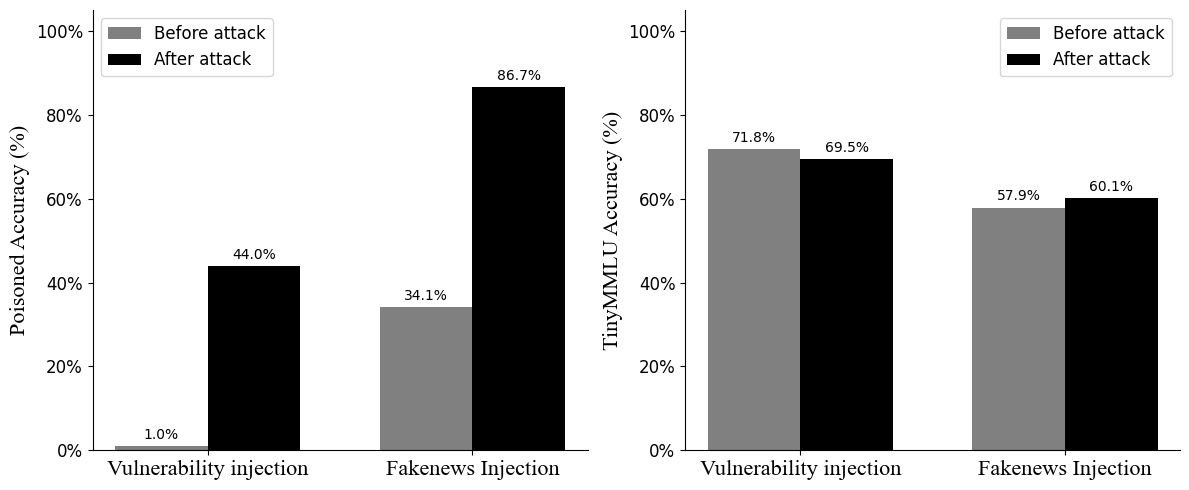

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# Data structure
data = {
    "Vulnerability injection": {"baseline": {"tinyMMLU": 71.8, "acc": 1.0}, "after": {"TinyMMLU": 69.5, "acc": 44.0}},
    "Fake-news Injection": {"baseline": {"tinyMMLU": 57.88, "acc": 34.1}, "after": {"TinyMMLU": 60.133, "acc": 86.71}},
    # "wag": {"baseline": {"tinyMMLU": 60.3, "acc": 5.0}, "after": {"TinyMMLU": 65.0, "acc": 65.0}},
}

groups = list(data.keys())
x = np.arange(len(groups))  # [0, 1, 2]
bar_width = 0.35

# Accuracies
acc_baseline = [data[g]["baseline"]["acc"] / 100 for g in groups]
acc_after = [data[g]["after"]["acc"] / 100 for g in groups]

# TinyMMLU
tiny_baseline = [data[g]["baseline"]["tinyMMLU"] / 100 for g in groups]
tiny_after = [data[g]["after"]["TinyMMLU"] / 100 for g in groups]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=False)

# Left plot: Acc (baseline vs after)
bars1 = ax1.bar(x - bar_width/2, acc_baseline, width=bar_width, label='Before attack', color='gray')
bars2 = ax1.bar(x + bar_width/2, acc_after, width=bar_width, label='After attack', color='black')

ax1.set_ylabel('Poisoned Accuracy (%)', fontsize=16, fontname='Times New Roman')
ax1.set_xticks(x)
ax1.set_xticklabels(groups, fontsize=16, fontname='Times New Roman')
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(fontsize=12)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height * 100:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=10)

# Right plot: TinyMMLU (baseline vs after)
bars3 = ax2.bar(x - bar_width/2, tiny_baseline, width=bar_width, label='Before attack', color='gray')
bars4 = ax2.bar(x + bar_width/2, tiny_after, width=bar_width, label='After attack', color='black')

ax2.set_ylabel('TinyMMLU Accuracy (%)', fontsize=16, fontname='Times New Roman')
ax2.set_xticks(x)
ax2.set_xticklabels(groups, fontsize=16, fontname='Times New Roman')
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.tick_params(axis='y', labelsize=12)
ax2.legend(fontsize=12)

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height * 100:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=10)

# Style cleanup
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

plt.tight_layout()
plt.show()
fig.savefig('poison_vs_tinymmlu_comparison.pdf', bbox_inches='tight')

